# Experiment 0 — Point Clouds and Observations

**Goal:** Introduce the synthetic data used throughout: five source cloud geometries, and the
observation model that degrades them with noise and dropout (§7).

The five geometries:
- `random` — uniform blob (near-spherical symmetry → ICP gets stuck in local minima)
- `clustered` — 8 dense Gaussian clusters (distinct spatial anchors)
- `lattice` — 3-D grid with anisotropic axis spacing (structured, axis-distinguishable)
- `2d-lattice` — flat, planar grid variant of `lattice` (near-degenerate depth)
- `muscle-fiber` — nuclei-like points on parallel, hexagonally packed fiber surfaces

For each style we visualise the source cloud and evaluate ICP accuracy over 30 random seeds.

In [1]:
import sys
sys.path.insert(0, '../src')

import numpy as np
import matplotlib.pyplot as plt

from icp import ICP
from experiment_runner import fit_multi_seed
from synthetic import SyntheticExperiment, CloudStyle
from visualization import PointCloudVisualizer, ErrorMetricsVisualizer

plt.style.use('seaborn-v0_8-whitegrid')

N_SEEDS = 30
SEEDS = list(range(N_SEEDS))
GEN_KWARGS = dict(n=2000, t_scale=8.0)
STYLES = ['random', 'clustered', 'lattice', '2d-lattice', 'muscle-fiber']
COLORS = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red', 'tab:purple']

icp = ICP(max_iter=400, tol=1e-10, verbose=False, record_history=False)

In [2]:
def visualize_cloud(style: CloudStyle, seed: int = 0) -> None:
    """Plot XY, XZ, YZ projections and a 3D view of the source cloud for a given style."""
    exp = SyntheticExperiment.generate(**GEN_KWARGS, seed=seed, style=style)
    fig = plt.figure(figsize=(16, 4))
    axes = [fig.add_subplot(1, 4, i + 1) for i in range(3)]
    PointCloudVisualizer.plot_projections(axes, exp.S)
    ax_3d = fig.add_subplot(1, 4, 4, projection='3d')
    PointCloudVisualizer.plot_scatter_3d(ax_3d, exp.S)
    ax_3d.set_title('3D')
    fig.suptitle(f'Source cloud — style={style!r}  (n={len(exp.S)})')
    plt.tight_layout()
    plt.savefig(f'../results/0_point_clouds_{style}_cloud.png', dpi=150, bbox_inches='tight')
    plt.show()

## 1. Random

Points drawn uniformly from $[-30, 30]^3$.  The resulting blob has approximate spherical symmetry — any rotation produces a nearly identical cloud, so nearest-neighbour matching provides no rotational signal and ICP gets trapped in local minima.

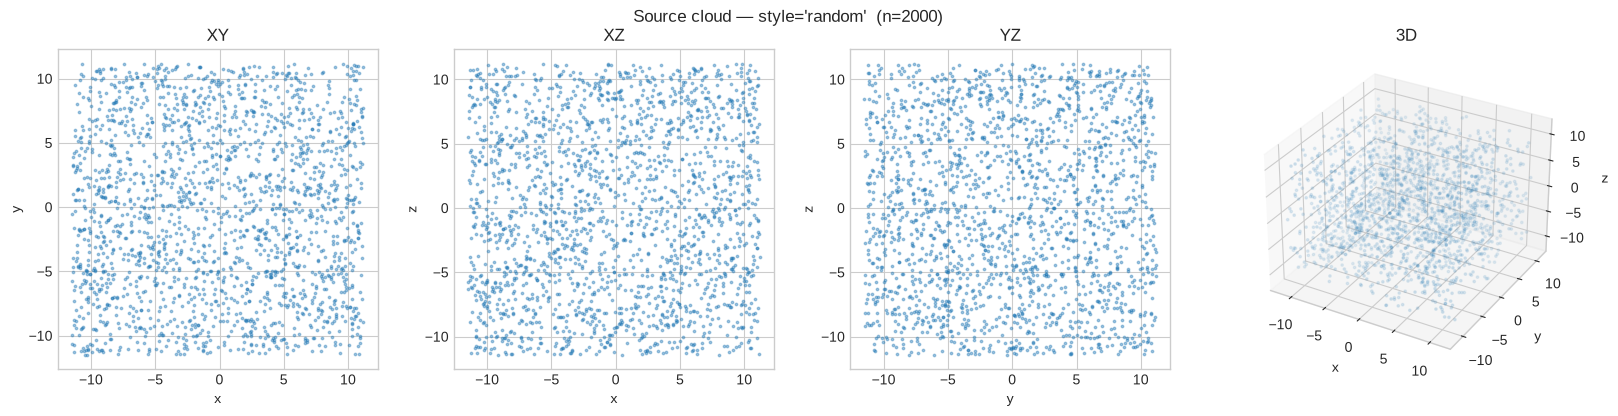

In [3]:
visualize_cloud('random')

## 2. Clustered

8 dense Gaussian clusters with centres placed randomly in $[-20, 20]^3$.  Each cluster acts as a distinct spatial anchor: an incorrect rotation that swaps two clusters incurs a large residual, giving ICP a strong signal to correct the alignment.

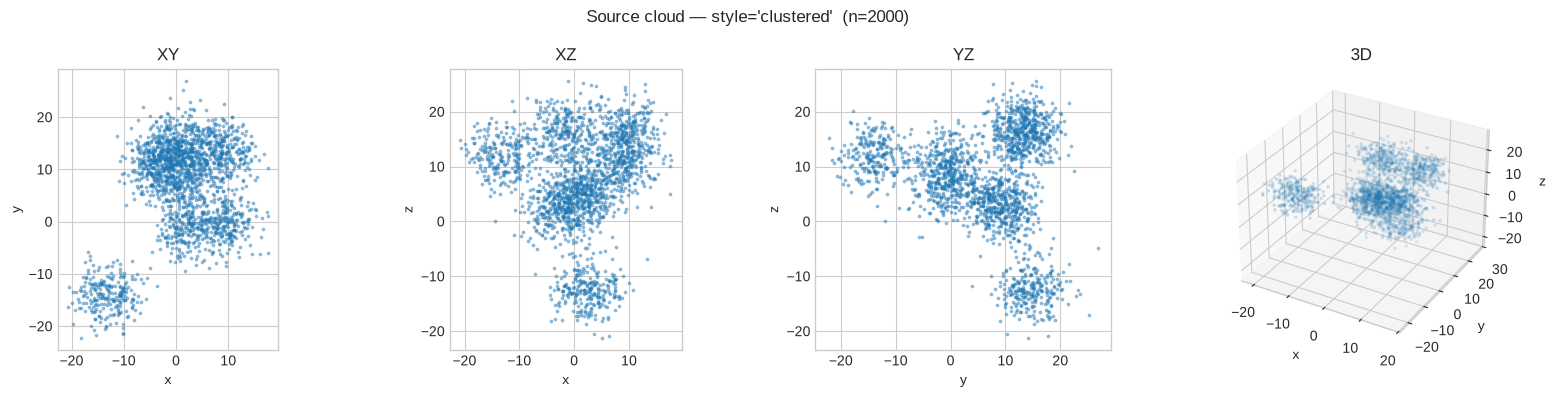

In [4]:
visualize_cloud('clustered')

## 3. Lattice

3-D regular grid with anisotropic spacing $(2, 3.5, 6)$ along $(x, y, z)$ and slight per-node jitter.  The different spacing per axis makes rotations distinguishable: swapping $x$ and $z$ visibly changes inter-point distances.

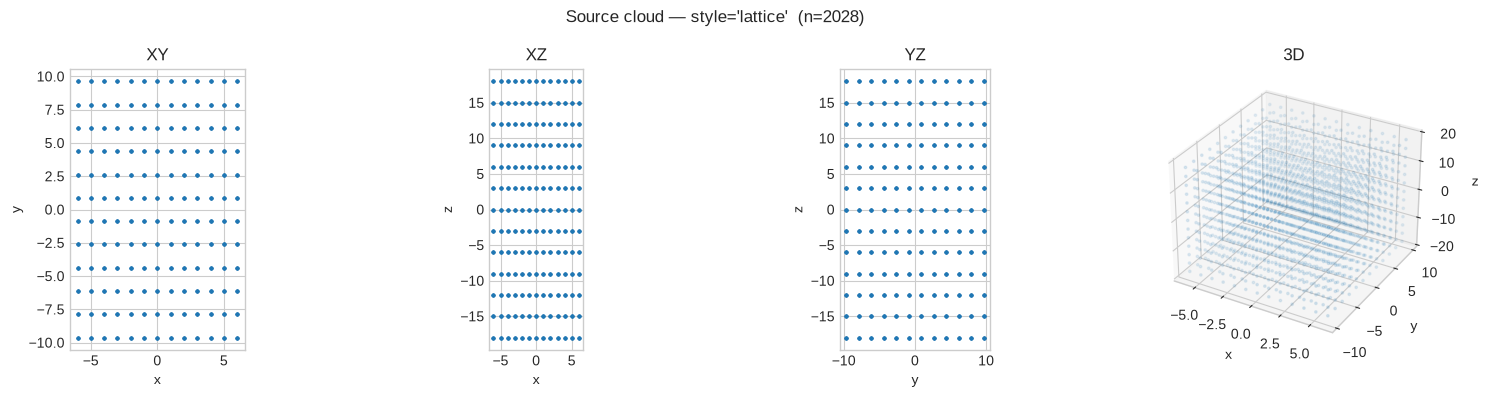

In [5]:
visualize_cloud('lattice')

## 4. 2D Lattice

Flat lattice confined to the XY plane ($z=0$) with anisotropic spacing $(2.0, 3.5)$ and no jitter. Every point has a highly planar local neighbourhood, making this a near-degenerate case: an out-of-plane rotation must be recovered from a cloud that has almost no depth to begin with.

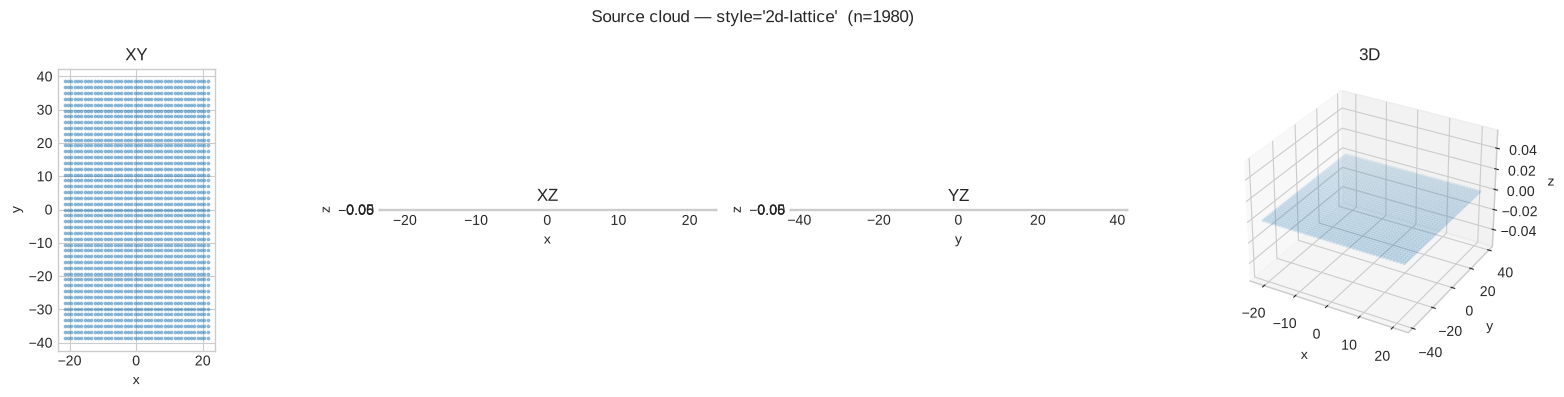

In [6]:
visualize_cloud('2d-lattice')

## 5. Muscle Fiber

Nuclei-like points on the periphery of parallel, hexagonally packed fibers (radius $3.0$, spacing $8.0$) — modelling the peripheral nuclear positioning of skeletal muscle fibers. Unlike the other styles, points form many small, separated ring-shaped clusters rather than one continuous blob, giving ICP a very different kind of local structure to exploit.

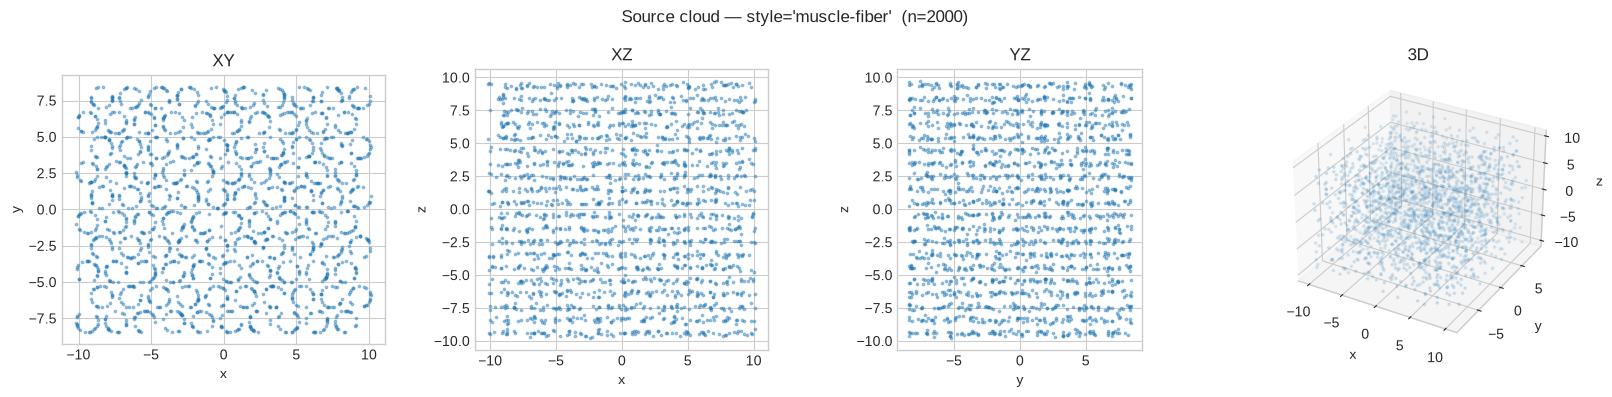

In [7]:
visualize_cloud('muscle-fiber')

## 6. Style comparison

All five styles on the same scale.

In [8]:
for style in ["random", "clustered", "lattice", "2d-lattice", "muscle-fiber"]:
    ms_random = fit_multi_seed(icp, SEEDS, experiment_kwargs={**GEN_KWARGS, 'style': style})

Solving 30 seeds: 100%|██████████| 30/30 [00:11<00:00,  2.52it/s, reliability=17%]


## 7. Observing a cloud: noise and dropout

Every later experiment fits two *observations* of a cloud, each made independently by
`PointCloudObserver`:

- **dropout** removes each point with probability `dropout_prob` — a point can survive on one
  side and be missing on the other, so not every point has a correspondent;
- **noise** adds Gaussian jitter with standard deviation `noise_std` to the surviving points.

Clouds are normalised to a median point spacing of 1, so `noise_std` is in units of point
spacing and means the same for every style. Below, two independent observations of the same
`clustered` cloud, in a thin slice around one point.

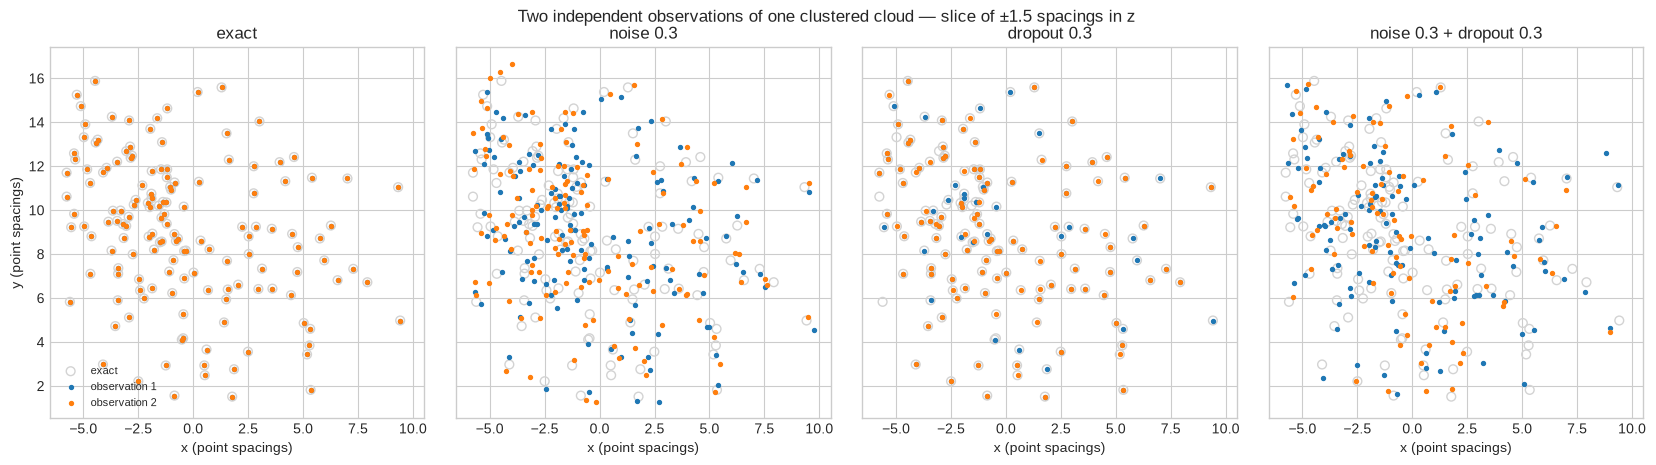

In [9]:
from synthetic import PointCloudObserver

OBSERVATION_LEVELS = {
    'exact': dict(),
    'noise 0.3': dict(noise_std=0.3),
    'dropout 0.3': dict(dropout_prob=0.3),
    'noise 0.3 + dropout 0.3': dict(noise_std=0.3, dropout_prob=0.3),
}
HALF_WIDTH = 8.0   # half-width of the plotted window, in point spacings
SLAB = 1.5         # half-thickness of the plotted slice along z


def slice_around(points: np.ndarray, centre: np.ndarray) -> np.ndarray:
    """Points inside the plotted window around `centre`.

    Args:
        points: (N, 3) array.
        centre: (3,) window centre.

    Returns:
        (M, 3) array of the points within HALF_WIDTH in x/y and SLAB in z.
    """
    offset = np.abs(points - centre)
    keep = (offset[:, 0] < HALF_WIDTH) & (offset[:, 1] < HALF_WIDTH) & (offset[:, 2] < SLAB)
    return points[keep]


cloud = SyntheticExperiment.generate(**GEN_KWARGS, seed=0, style='clustered').S
centre = cloud.points[0]
fig, axes = plt.subplots(1, len(OBSERVATION_LEVELS), figsize=(4.2 * len(OBSERVATION_LEVELS), 4.4),
                         sharex=True, sharey=True)
for ax, (label, level) in zip(axes, OBSERVATION_LEVELS.items()):
    observer = PointCloudObserver(seed=0, **level)
    exact = slice_around(cloud.points, centre)
    ax.scatter(exact[:, 0], exact[:, 1], s=40, facecolors='none', edgecolors='lightgrey', label='exact')
    for i, color in enumerate(['tab:blue', 'tab:orange']):
        observed = slice_around(observer.observe(cloud).points, centre)
        ax.scatter(observed[:, 0], observed[:, 1], s=8, color=color, label=f'observation {i + 1}')
    ax.set(title=label, aspect='equal', xlabel='x (point spacings)')
axes[0].set_ylabel('y (point spacings)')
axes[0].legend(fontsize=8, loc='lower left')
fig.suptitle(f'Two independent observations of one clustered cloud — slice of ±{SLAB} spacings in z')
fig.tight_layout()
fig.savefig('../results/0_point_clouds_observation.png', dpi=150, bbox_inches='tight')
plt.show()

### Observations

- **Noise moves every point**, so the two observations no longer coincide anywhere, although
  each point stays close to where it was.
- **Dropout leaves survivors exactly in place**, but each observation misses a different
  subset, so some points have no partner on the other side.
- Combined, both effects apply: fewer shared points, and none of them in exactly the same place.

# Conclusion
- Different cloud styles exist
- naive ICP performance is best for *lattice* and *clustered*
- Observations are degraded by independent dropout and noise; noise is measured in point spacings
